In [16]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"

path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha2_Loc5_True19_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha2_Loc5_True19_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha2_Loc5_True19_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)

xa1    = data1['xa'][:]
yo1    = data1['yo'][:]
atemp1 = data1['steps'][:]
ox1,oy1,oz1 = data1['ox'][:], data1['oy'][:], data1['oz'][:]
deps1 = data1['deps'][:]
print('deps1', deps1.shape)
print('Shape xa1', xa1.shape)
print(f'yo {yo1.shape}')
print(f'steps {atemp1}')

xa2    = data2['xa'][:]
yo2    = data2['yo'][:]
atemp2 = data2['steps'][:]
ox2,oy2,oz2 = data2['ox'][:], data2['oy'][:], data2['oz'][:]
deps2 = data2['deps'][:]
print('Shape xa2', xa2.shape)
print(f'yo {yo2.shape}')
print(f'steps {atemp2}')

xa3    = data3['xa'][:]
yo3    = data3['yo'][:]
atemp3 = data3['steps'][:]
ox3,oy3,oz3 = data3['ox'][:], data3['oy'][:], data3['oz'][:]
deps3 = data3['deps'][:]
print('Shape xa3', xa3.shape)
print(f'yo3 {yo3.shape}')
print(f'steps {atemp3}')

deps1 (1, 43)
Shape xa1 (77, 1, 43, 29, 8)
yo (43,)
steps [1.]
Shape xa2 (77, 1, 43, 29, 8)
yo (43,)
steps [0.04742587 0.95257413]
Shape xa3 (77, 1, 43, 29, 8)
yo3 (43,)
steps [0.00380626 0.20781451 0.78837925]


In [17]:
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda

truth = data1['truth'][:]
xn,yn,zn = xa1.shape[0:3]
ref = np.zeros((xn,yn,zn))
for xi in np.arange(xn):
    for yi in np.arange(yn):
        for zi in np.arange(zn):
            qr = truth[xi, yi, zi, 1]
            qs = truth[xi, yi, zi, 2]
            qg = truth[xi, yi, zi, 0]
            tt = truth[xi, yi, zi, 3]
            pp = truth[xi, yi, zi, 4]

            ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)

In [18]:
def tight_bbox_from_field(field2d, threshold=0.0, pad=2):
    """
    Return (xmin, xmax, zmin, zmax) axis limits in index space for
    the region where field2d > threshold. pad is in grid cells.
    """
    a = np.asarray(field2d)
    mask = a > threshold
    if not np.any(mask):
        # fall back to full domain
        xn, zn = a.shape
        return -0.5, xn - 0.5, -0.5, zn - 0.5
    ix, iz = np.where(mask)           # ix ~ x-index (first dim), iz ~ z-index (second dim)
    xn, zn = a.shape
    xmin = max(ix.min() - pad, 0)
    xmax = min(ix.max() + pad, xn - 1)
    zmin = max(iz.min() - pad, 0)
    zmax = min(iz.max() + pad, zn - 1)
    # use half-cell edges for pretty bounds
    return xmin - 0.5, xmax + 0.5, zmin - 0.5, zmax + 0.5

def plot_observations(data):
    truth = data['truth'][:]
    xa    = data['xa'][:]
    hxf   = data['hxf'][:]
    xn,yn,zn = xa.shape[0:3]
    yo1    = data['yo'][:]
    atemp1 = data['steps'][:]
    ox1,oy1,oz1 = data['ox'][:], data['oy'][:], data['oz'][:]
    deps1 = data['deps'][:]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    fig, ax = plt.subplots(1, 3, figsize=(20, 4.5),dpi=300, facecolor='white')
    im=ax[0].scatter(ox1,oz1,c=yo1,cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)

    fig.colorbar(im, ax=ax[0], label="Reflectivity (dBZ)")
    ax[0].set_title(f'Observations  $[y_0] (Nobs = {len(yo1)})$',fontsize=20)
    ax[0].set_aspect('equal','box')

    X, Z = np.meshgrid(np.arange(xn), np.arange(zn), indexing='ij')
    #im3 = ax[1].scatter(X.flatten(), Z.flatten(), c=ref[:,0,:].flatten(), cmap='Spectral_r', marker='o', s=10,vmin=0,vmax=50)
    #im2 = ax[1].pcolormesh(X, Z, hxf, cmap="Spectral_r", vmin=5, vmax=40, shading='auto')
    im2  = ax[1].scatter(ox1, oz1, c=np.nanmean(hxf[0,:,:],axis=1),cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)
    #cd  = ax[1].scatter(ox1, oz1, s=12, color="white", alpha=0.6, edgecolor="none", rasterized=True)
    fig.colorbar(im2, ax=ax[1], label="Reflectivity (dBZ)")
    ax[1].set_title('Ensemble mean $ [\overline{ H[x_f] }]$',fontsize=20)
    ax[1].set_aspect('equal','box')

    im=ax[2].scatter(ox1,oz1,c=deps1,cmap='RdBu_r', marker='o', edgecolor="k", s=35,vmin=-20,vmax=20)

    fig.colorbar(im, ax=ax[2], label="Reflectivity (dBZ)")
    ax[2].set_title('Departure $[y_0 - \overline{ H[x_f] }]$',fontsize=20)
    ax[2].set_aspect('equal','box')

    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    for a in ax:
        a.set_xlim(xmin, xmax)
        a.set_ylim(zmin, zmax)
        a.set_aspect('equal', 'box')
        cs = a.contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
        a.clabel(cs, fmt="%.0f", inline=True, fontsize=8)
    plt.tight_layout()
    plt.savefig('Observations_EnsembleMean_Departure.png', dpi=300)



    plt.show()

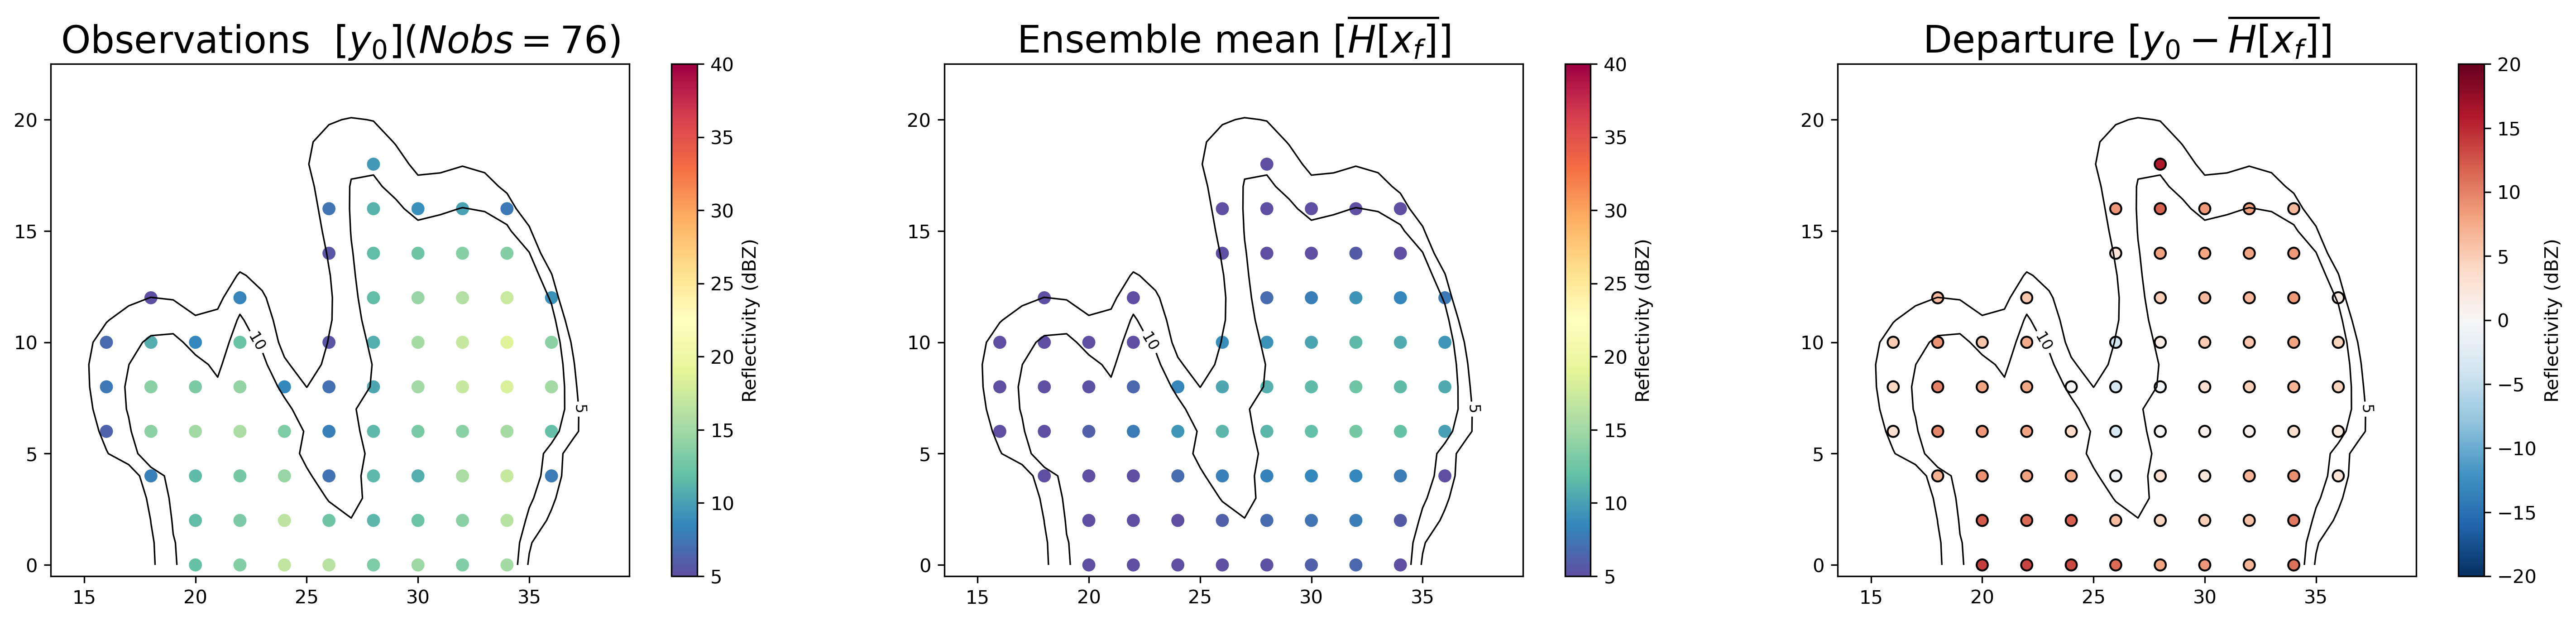

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
alpha=2
loc=5
true=20                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_observations(data1)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def plot_error_analysis(data1, data2, data3):
    # Define file paths
    truth = data1['truth'][:]
    xa    = data1['xa'][:]
    xn,yn,zn = xa.shape[0:3]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    file_paths = {
        'LETKF'   : data1,
        'LETKF-T2': data2,
        'LETKF-T3': data3
    }

    # Variable names
    variables = {
        0: 'Graupel',
        3: 'Temperature',
        7: 'Vertical Wind'
    }

    fig, axs = plt.subplots(3, 3, figsize=(18, 12), facecolor='white')
    for i, (var_index, var_name) in enumerate(variables.items()):
        contour_levels = {}  # Store contour levels and ticks per row
        err_maxs = []
        for col_index, (col_name, data) in enumerate(file_paths.items()):
            xa = data['xa'][:, 0, :, :, :]
            true_state = data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            idx_zero = true_field == 0
            true_field[idx_zero] = np.nan  # Set to NaN to avoid division by zero
            error_analysis = analysis_field - true_field        #print(f'Error analysis shape: {error_analysis}')
            err_maxs.append(np.nanmax(np.abs(error_analysis)))

        err_max = np.nanmax(err_maxs)
        contour_levels['error'] = np.linspace(-err_max, err_max, 20)

        for col_index, (col_name, data) in enumerate(file_paths.items()):
            xa = data['xa'][:, 0, :, :, :]
            true_state = data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            # Avoid division by zero

            error_analysis = analysis_field - true_field
            # Analysis Error
            im = axs[i, col_index].contourf(error_analysis.T, cmap='RdBu_r', levels=contour_levels['error'])
            cb2 = fig.colorbar(im, ax=axs[i, col_index])
            rmse = np.sqrt(mean_squared_error(true_field, analysis_field))
            axs[i, col_index].set_title(f"{col_name} | RMSE: {rmse:.3f} ",fontsize=20)
            cs = axs[i, col_index].contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
            axs[i, col_index].clabel(cs, fmt="%.0f", inline=True, fontsize=12)
            # Grid every 2 units and add square
            for ax in axs[:, col_index]:
                ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
                #ax.set_xticks(np.arange(0, forecast_field.shape[0], 5))
                #ax.set_yticks(np.arange(0, forecast_field.shape[1], 5))
            if col_index == 0:
                axs[i, col_index].set_ylabel(f"{var_name}", fontsize=20)
        # General title
        #fig.suptitle(f"Variable: {var_name}", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Error_Analysis_Multiple_Obs.png', dpi=300,transparent=False)
    plt.show()

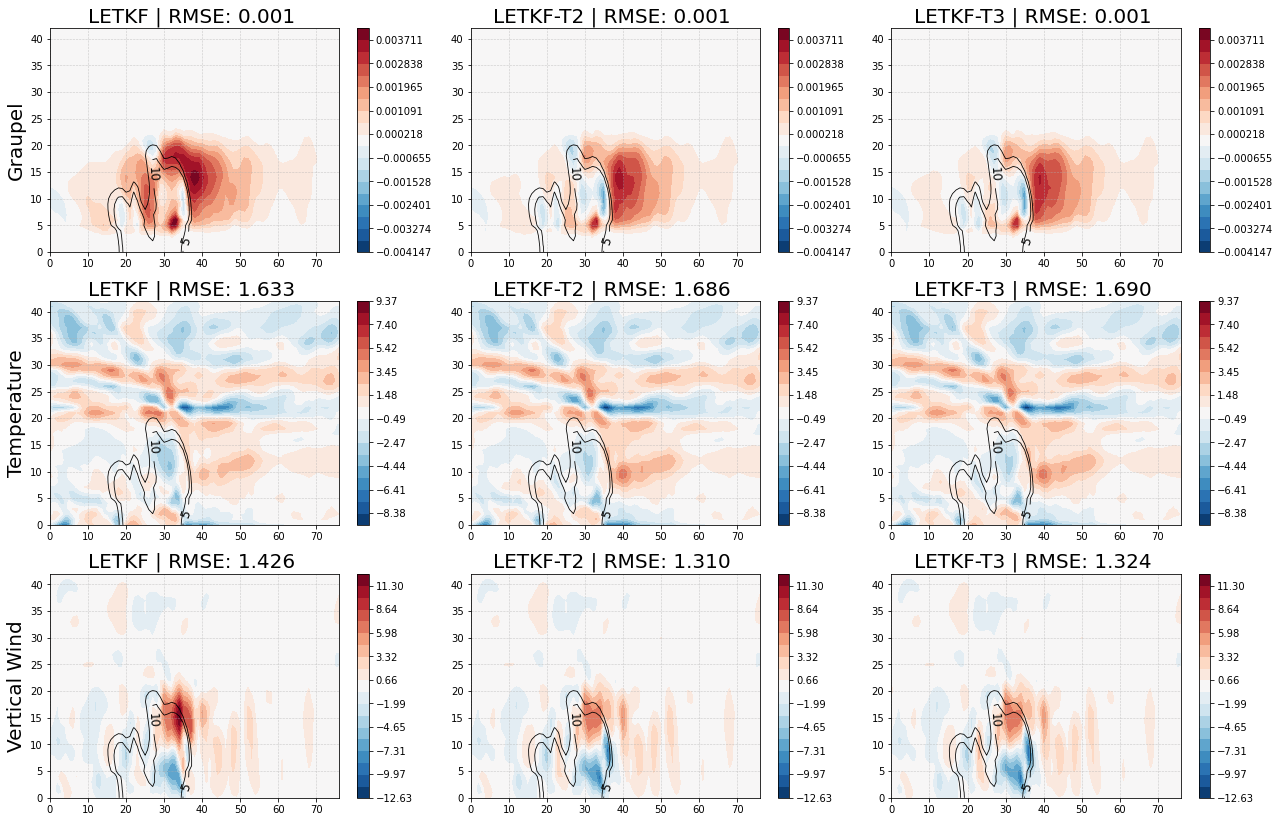

In [30]:
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
figpath_error = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/error/"
figpath_obs = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/observations/"
alpha_range = [0,1,2,3]
loc_range = [-1,1,2,3,4,5,6,7,8,9,10]
nens_range = np.arange(30)

alpha=0
loc=5
true=20                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_error_analysis(data1, data2, data3)

In [31]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_squared_error

def compute_rmse_summary(outdir, alphas, ntemps, truth_member=20, loc_scale=5):
    """
    Compute RMSE summary table for all alpha/ntemp combinations
    """
    var_names = ['Graupel', 'Temperature', 'Vertical Wind']
    var_indices = [0, 3, 7]  # qg, T, w
    
    results = []
    
    for alpha in alphas:
        for ntemp in ntemps:
            # Construct filename
            tag = f"Multicycle_v2_2023-12-16_19:00:00_temp{ntemp}_alpha{int(alpha)}_Loc{int(loc_scale)}_True{int(truth_member)}_kindFULL_2D"
            filepath = Path(outdir) / f"{tag}.npz"
            
            if not filepath.exists():
                print(f"Warning: {filepath} not found")
                continue
            
            # Load data
            data = np.load(filepath)
            xa = data['xa'][:, 0, :, :, :]  # [nx, nz, Ne, nvar]
            truth = data['truth'][:, 0, :, :]  # [nx, nz, nvar]
            
            # Compute mean analysis
            mean_xa = np.nanmean(xa, axis=2)  # [nx, nz, nvar]
            
            # Compute RMSE for each variable
            row = {'alpha': alpha, 'ntemp': ntemp}
            for var_name, var_idx in zip(var_names, var_indices):
                analysis_field = mean_xa[:, :, var_idx]
                true_field = truth[:, :, var_idx]
                
                # Remove NaN values
                mask = ~(np.isnan(analysis_field) | np.isnan(true_field))
                if mask.sum() > 0:
                    rmse = np.sqrt(mean_squared_error(
                        true_field[mask].flatten(), 
                        analysis_field[mask].flatten()
                    ))
                    row[var_name] = rmse
                else:
                    row[var_name] = np.nan
            
            results.append(row)
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    # Sort by alpha and ntemp
    df = df.sort_values(['alpha', 'ntemp']).reset_index(drop=True)
    
    return df

# Usage:
outdir = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle"
alphas = [0, 1, 2, 3]
ntemps = [1, 2, 3]

df = compute_rmse_summary(outdir, alphas, ntemps)

# Display table
print("\n" + "="*70)
print("RMSE SUMMARY TABLE")
print("="*70)
print(df.to_string(index=False, float_format='%.3f'))
print("="*70)

# Find best configuration for each variable
print("\nBEST CONFIGURATIONS:")
for var in ['Graupel', 'Temperature', 'Vertical Wind']:
    best_idx = df[var].idxmin()
    best_row = df.loc[best_idx]
    print(f"{var:20s}: alpha={int(best_row['alpha'])}, ntemp={int(best_row['ntemp'])}, RMSE={best_row[var]:.3f}")

# Save to CSV
df.to_csv('rmse_summary.csv', index=False, float_format='%.4f')
print("\nTable saved to: rmse_summary.csv")


RMSE SUMMARY TABLE
 alpha  ntemp  Graupel  Temperature  Vertical Wind
     0      1    0.001        1.633          1.426
     0      2    0.001        1.686          1.310
     0      3    0.001        1.690          1.324
     1      1    0.001        1.633          1.426
     1      2    0.001        1.716          1.346
     1      3    0.001        1.715          1.319
     2      1    0.001        1.633          1.426
     2      2    0.001        1.731          1.331
     2      3    0.001        1.738          1.331
     3      1    0.001        1.633          1.426
     3      2    0.001        1.732          1.340
     3      3    0.001        1.731          1.355

BEST CONFIGURATIONS:
Graupel             : alpha=2, ntemp=3, RMSE=0.001
Temperature         : alpha=0, ntemp=1, RMSE=1.633
Vertical Wind       : alpha=0, ntemp=2, RMSE=1.310

Table saved to: rmse_summary.csv


In [32]:
def tempering_steps(ntemp: int, alpha: float) -> np.ndarray:
    if ntemp < 1:
        return np.array([1.0], dtype=np.float32)
    dt = 1.0 / (ntemp + 1)
    grid = np.arange(dt, 1.0 - dt/100.0, dt)
    steps = np.exp(alpha / grid)
    steps = (1/steps) / np.sum((1/steps))
    #steps /= steps.sum()
    #steps = (1.0 / steps) / (1.0 / steps).sum()
    return steps.astype("float32")

print("\n" + "="*50)
print("TEMPERING WEIGHT SCHEDULES")
print("="*50)
for alpha in [0, 1, 2, 3]:
    print(f"\nAlpha = {alpha}:")
    for ntemp in [1, 2, 3]:
        steps = tempering_steps(ntemp, alpha)
        print(f"  ntemp={ntemp}: {steps} (sum={steps.sum():.3f})")
        if ntemp > 1:
            # Show R inflation factors
            r_inflation = 1.0 / steps
            print(f"            R inflation: {r_inflation}")


TEMPERING WEIGHT SCHEDULES

Alpha = 0:
  ntemp=1: [1.] (sum=1.000)
  ntemp=2: [0.5 0.5] (sum=1.000)
            R inflation: [2. 2.]
  ntemp=3: [0.33333334 0.33333334 0.33333334] (sum=1.000)
            R inflation: [3. 3. 3.]

Alpha = 1:
  ntemp=1: [1.] (sum=1.000)
  ntemp=2: [0.18242553 0.8175745 ] (sum=1.000)
            R inflation: [5.481689  1.2231301]
  ntemp=3: [0.04389628 0.3243521  0.6317516 ] (sum=1.000)
            R inflation: [22.780972   3.0830693  1.5829006]

Alpha = 2:
  ntemp=1: [1.] (sum=1.000)
  ntemp=2: [0.04742587 0.95257413] (sum=1.000)
            R inflation: [21.085537  1.049787]
  ntemp=3: [0.00380626 0.20781451 0.78837925] (sum=1.000)
            R inflation: [262.7254      4.8119836   1.2684251]

Alpha = 3:
  ntemp=1: [1.] (sum=1.000)
  ntemp=2: [0.01098694 0.9890131 ] (sum=1.000)
            R inflation: [91.01713   1.011109]
  ntemp=3: [2.9538723e-04 1.1916771e-01 8.8053691e-01] (sum=1.000)
            R inflation: [3.3853867e+03 8.3915348e+00 1.1356708e